In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import scale_range
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv('breast-cancer.csv')
df.head()

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


#### 检查缺失值

In [2]:
df.isnull().sum()

age             0
mefalsepause    0
tumor-size      0
inv-falsedes    0
falsede-caps    8
deg-malig       0
breast          0
breast-quad     1
irradiat        0
class           0
dtype: int64

#### 填充缺失值

In [3]:
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df_imputed.isnull().sum()

age             0
mefalsepause    0
tumor-size      0
inv-falsedes    0
falsede-caps    0
deg-malig       0
breast          0
breast-quad     0
irradiat        0
class           0
dtype: int64

#### 将分类变量转换为数值

In [4]:
label_encoders = {}
for col in df_imputed.columns:
    if df_imputed[col].dtype == 'object':
        le = LabelEncoder()
        df_imputed[col] = le.fit_transform(df_imputed[col])
        label_encoders[col] = le

df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           272 non-null    int64
 1   mefalsepause  272 non-null    int64
 2   tumor-size    272 non-null    int64
 3   inv-falsedes  272 non-null    int64
 4   falsede-caps  272 non-null    int64
 5   deg-malig     272 non-null    int64
 6   breast        272 non-null    int64
 7   breast-quad   272 non-null    int64
 8   irradiat      272 non-null    int64
 9   class         272 non-null    int64
dtypes: int64(10)
memory usage: 21.4 KB


#### 数据标准化

In [6]:
X = df_imputed.drop('class', axis=1)
y = df_imputed['class']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat
0,-0.651884,0.937776,-0.977895,-0.568719,1.986317,1.28,1.052866,0.188502,-0.57169
1,0.338688,-1.094694,-0.977895,-0.568719,-0.503444,-1.44,1.052866,-1.642660,-0.57169
2,0.338688,-1.094694,0.875676,-0.568719,-0.503444,-0.08,-0.949788,-0.727079,-0.57169
3,-0.651884,0.937776,0.875676,-0.568719,1.986317,1.28,1.052866,-0.727079,1.74920
4,-0.651884,0.937776,0.412283,1.480176,1.986317,-0.08,-0.949788,2.019664,-0.57169


#### 可视化：目标变量分布

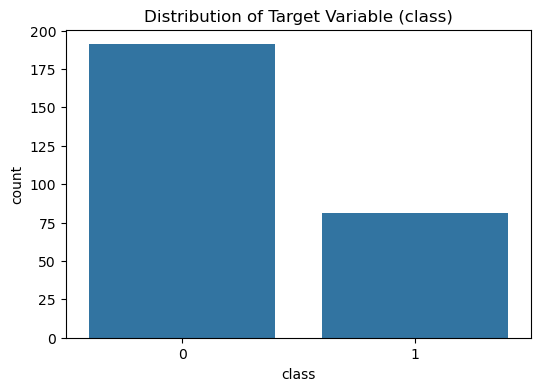

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (class)')
plt.show()

#### 可视化：数值型特征的分布

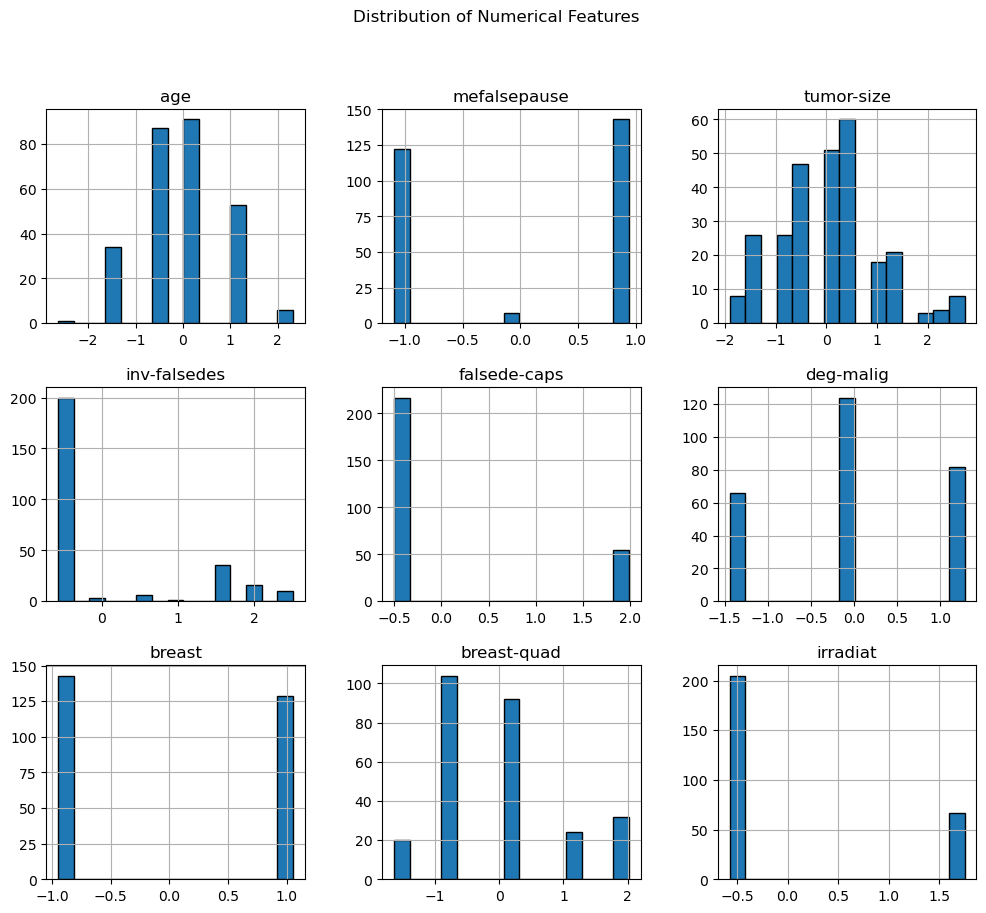

In [8]:
num_features = X_scaled.select_dtypes(include=[np.number]).columns
X_scaled[num_features].hist(bins=15, figsize=(12,10), edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

#### 可视化：特征与目标变量的箱线图

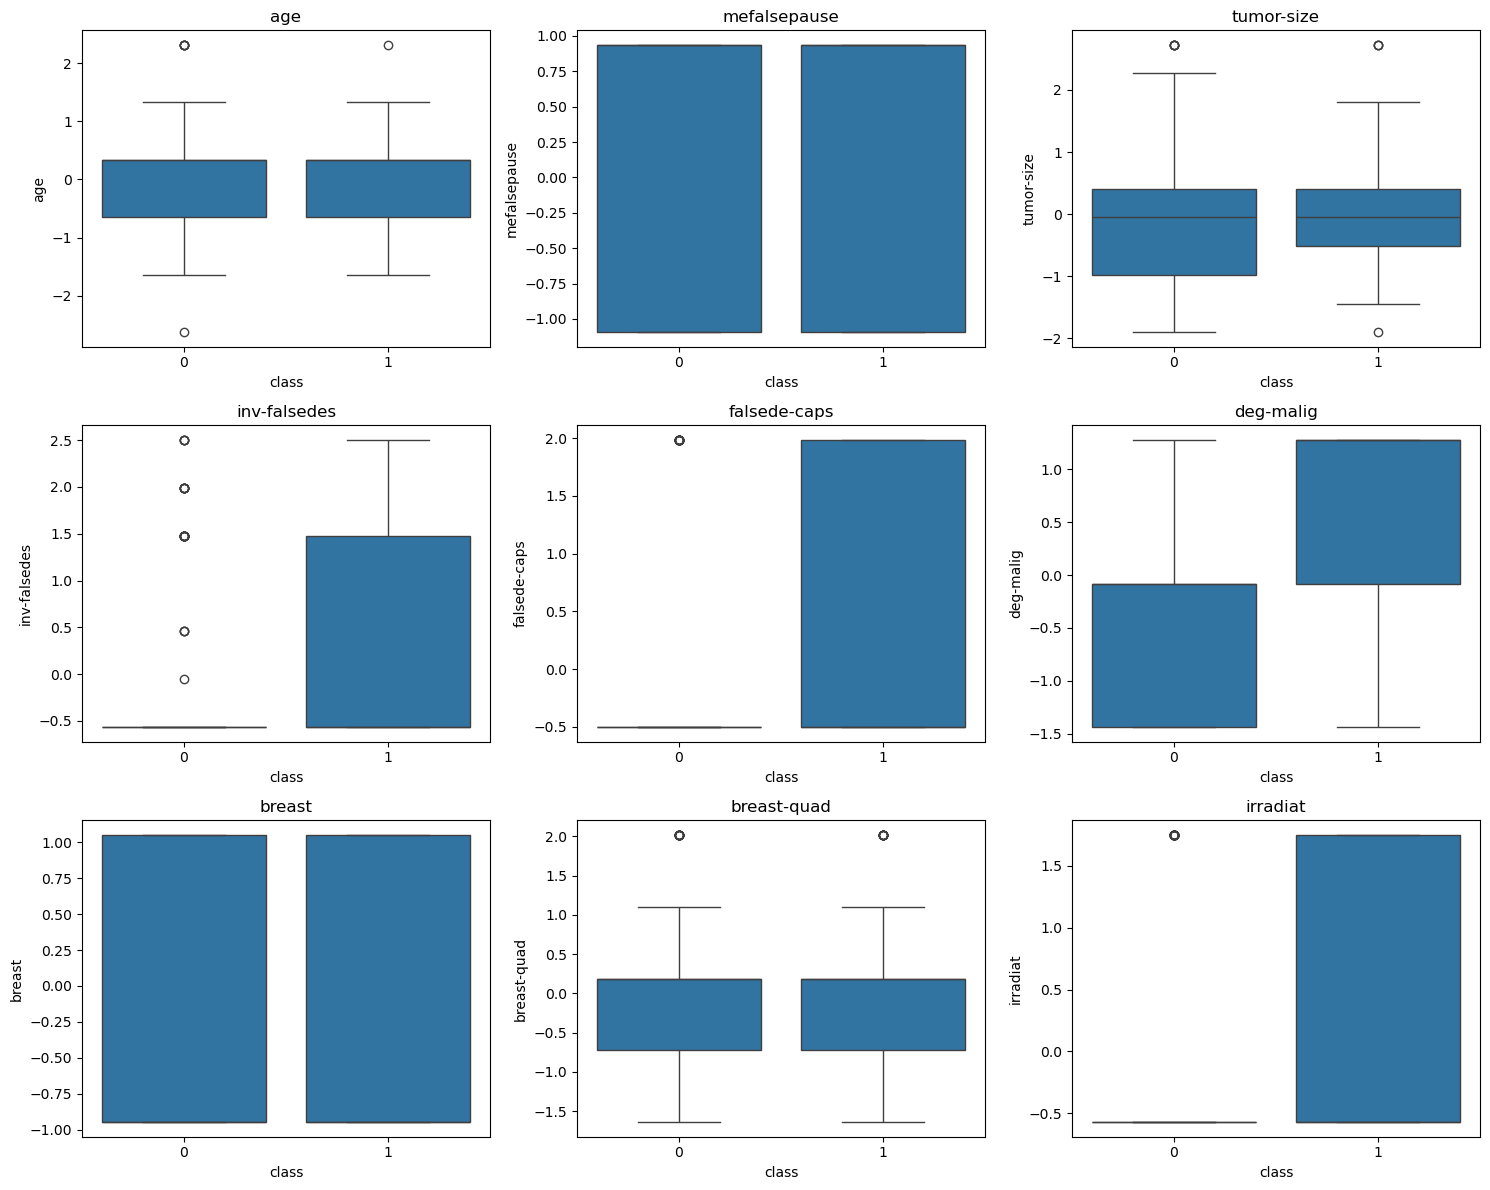

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten()
for i, col in enumerate(num_features[:9]):
    sns.boxplot(x=y, y=X_scaled[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#### 计算并可视化特征相关性

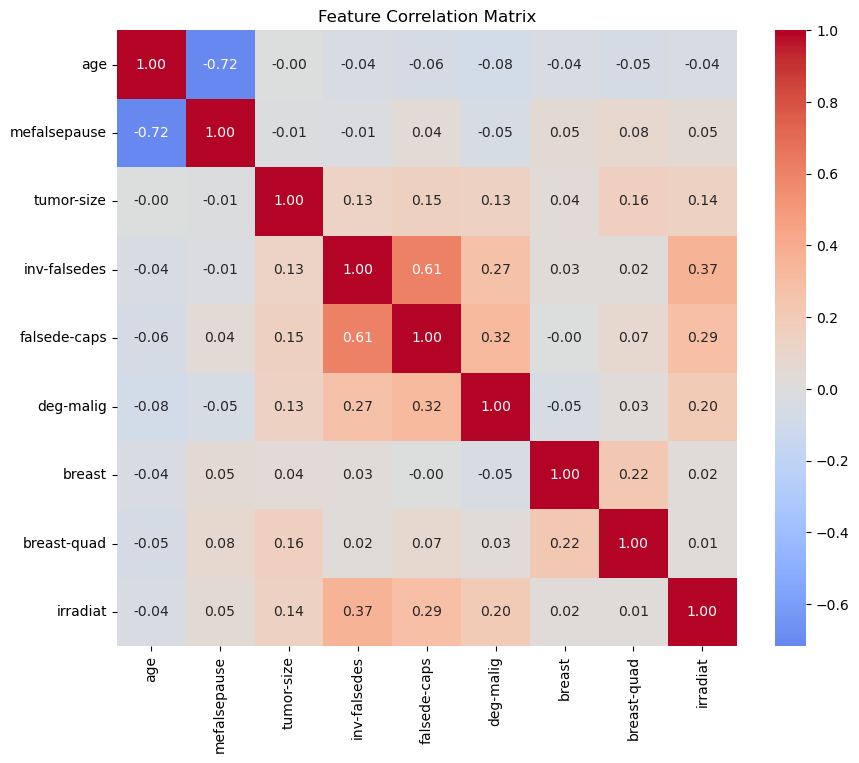

In [10]:
corr_matrix = X_scaled.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

#### 使用随机森林计算特征重要性

In [11]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
importances = rf.feature_importances_
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)
feature_importances_df

,feature,importance
2,tumor-size,0.241202
7,breast-quad,0.141319
5,deg-malig,0.135324
0,age,0.134688
3,inv-falsedes,0.107190
6,breast,0.072171
1,mefalsepause,0.058416
4,falsede-caps,0.057080
8,irradiat,0.052610


#### 可视化特征重要性

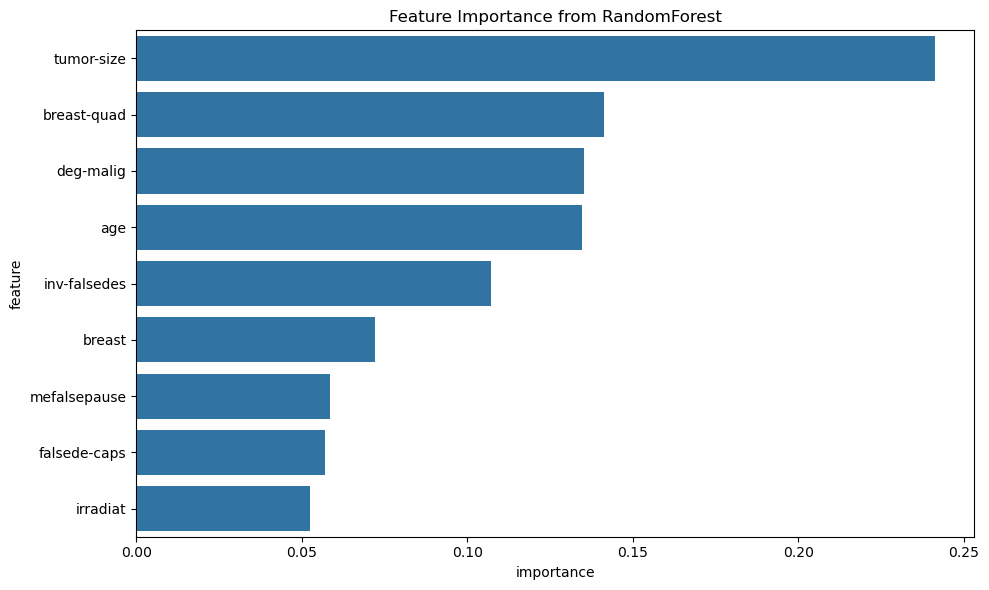

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importances_df)
plt.title('Feature Importance from RandomForest')
plt.tight_layout()
plt.show()